# Анализ удовлетворённости клиентов

Исследовательский вопрос: **Какие факторы (продукт, тема отзыва, сегмент клиента, платформа) определяют удовлетворённость клиента, и что сильнее всего драйвит негатив?**

## 1. Preprocessing & Feature Engineering

In [89]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from src.utils.helpers import configure_plots, save_figure, top_n_encoder
from src.data.preprocessor import load_data, preprocess, create_target, fill_missing_segments
from src.analysis.visualize import *
from src.analysis.stats import *

configure_plots()

In [90]:
df = load_data()
df = preprocess(df)
df = create_target(df)
df = fill_missing_segments(df)
print(f'Shape: {df.shape}')
print(f'detractors: {df["is_detractor"].mean():.1%}')

Shape: (56820, 33)
detractors: 39.2%


## 2. Дескриптивный анализ удовлетворённости

### 2a. Связь трёх метрик: csat_score, review_mark, review_emotion

In [91]:
# csat_score vs review_emotion
pd.crosstab(
    df.dropna(subset=['csat_score'])['csat_score'],
    df.dropna(subset=['csat_score'])['review_emotion'],
    normalize='columns'
).round(3)

review_emotion,Негативный,Позитивный
csat_score,,
1.0,0.816,0.066
2.0,0.033,0.000
3.0,0.028,0.016
4.0,0.017,0.016
5.0,0.106,0.902


In [92]:
# review_mark (числовой) vs review_emotion
mark_data = df[df['has_numeric_mark']]
ct = pd.crosstab(mark_data['review_mark_num'], mark_data['review_emotion'], normalize='columns').round(3)
ct

review_emotion,Негативный,Позитивный
review_mark_num,,
1.0,0.864,0.000
2.0,0.095,0.000
3.0,0.041,0.000
4.0,0.000,0.017
5.0,0.000,0.983


In [93]:
# Противоречия: позитивная эмоция + низкая оценка
contradictions = df[(df['review_emotion'] == 'Негативный') & (df['review_mark_num'] >= 4)]
print(f'Негативная эмоция + оценка 4-5: {len(contradictions)} отзывов ({len(contradictions)/len(df):.1%})')

contradictions2 = df[(df['review_emotion'] == 'Позитивный') & (df['review_mark_num'] <= 2)]
print(f'Позитивная эмоция + оценка 1-2: {len(contradictions2)} отзывов ({len(contradictions2)/len(df):.1%})')

Негативная эмоция + оценка 4-5: 0 отзывов (0.0%)
Позитивная эмоция + оценка 1-2: 0 отзывов (0.0%)


### 2a-2. Корреляционный анализ метрик

In [94]:
from scipy.stats import pearsonr, spearmanr
from src.analysis.stats import cramers_v

# 1) Pearson: review_mark_num vs csat_score
mask = df['has_numeric_mark'] & df['csat_score'].notna()
r_pearson, p_pearson = pearsonr(df.loc[mask, 'review_mark_num'], df.loc[mask, 'csat_score'])
print(f'=== Pearson: review_mark_num vs csat_score ===')
print(f'r = {r_pearson:.3f}, p = {p_pearson:.2e}  (n={mask.sum()})')
print()

# 2) Spearman: review_mark_num vs review_emotion (числовое кодирование)
emotion_map = {'Негативный': 1, 'Нейтральный': 2, 'Позитивный': 3}
df_num = df[df['has_numeric_mark']].copy()
df_num['emotion_num'] = df_num['review_emotion'].map(emotion_map)
r_spear, p_spear = spearmanr(df_num['review_mark_num'], df_num['emotion_num'])
print(f'=== Spearman: review_mark_num vs review_emotion ===')
print(f'rho = {r_spear:.3f}, p = {p_spear:.2e}  (n={len(df_num)})')
print()

# 3) Spearman: csat_score vs review_emotion (только записи с CSAT)
csat_df = df.dropna(subset=['csat_score']).copy()
csat_df['emotion_num'] = csat_df['review_emotion'].map(emotion_map)
r_spear2, p_spear2 = spearmanr(csat_df['csat_score'], csat_df['emotion_num'])
print(f'=== Spearman: csat_score vs review_emotion ===')
print(f'rho = {r_spear2:.3f}, p = {p_spear2:.2e}  (n={len(csat_df)})')
print()

# 4) Cramér's V: review_emotion vs csat_score
ct = pd.crosstab(df.dropna(subset=['csat_score'])['csat_score'], df.dropna(subset=['csat_score'])['review_emotion'])
v = cramers_v(ct)
print(f'=== Cramér\'s V: review_emotion vs csat_score ===')
print(f'V = {v:.3f}')

=== Pearson: review_mark_num vs csat_score ===
r = 0.436, p = 2.10e-96  (n=2064)

=== Spearman: review_mark_num vs review_emotion ===
rho = 0.977, p = 0.00e+00  (n=45937)

=== Spearman: csat_score vs review_emotion ===
rho = 0.271, p = 2.00e-58  (n=3407)

=== Cramér's V: review_emotion vs csat_score ===
V = 0.325


Saved: C:\Users\Admin\Documents\PARA\Projects\product-analytics-intensive-case-tbank\reports\figures\csat_vs_emotion_heatmap.png


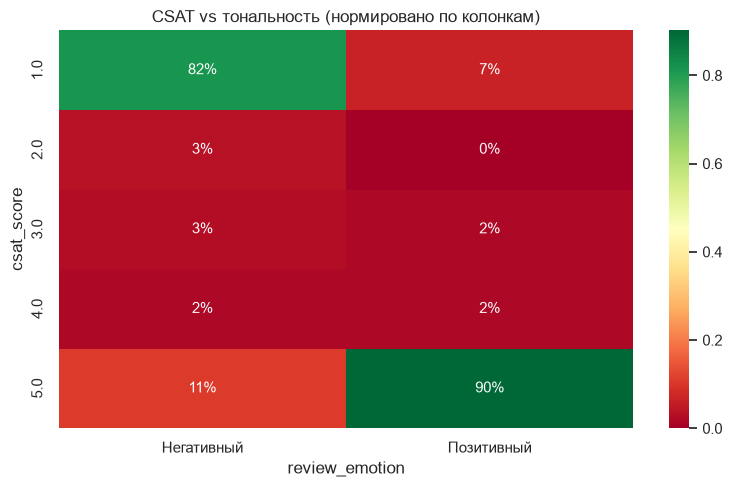

In [95]:
# Heatmap: csat_score vs review_emotion
csat_cross = pd.crosstab(
    df.dropna(subset=['csat_score'])['csat_score'],
    df.dropna(subset=['csat_score'])['review_emotion'],
    normalize='columns'
)
plot_satisfaction_heatmap(csat_cross, 'CSAT vs тональность (нормировано по колонкам)', fmt='.0%')
save_figure('csat_vs_emotion_heatmap.png')

### 2b. Удовлетворённость по продуктам и бизнес-линиям

In [113]:
import importlib
import src.analysis.visualize
importlib.reload(src.analysis.visualize)
from src.analysis.visualize import *

Saved: C:\Users\Admin\Documents\PARA\Projects\product-analytics-intensive-case-tbank\reports\figures\worst_products_avg_mark.png


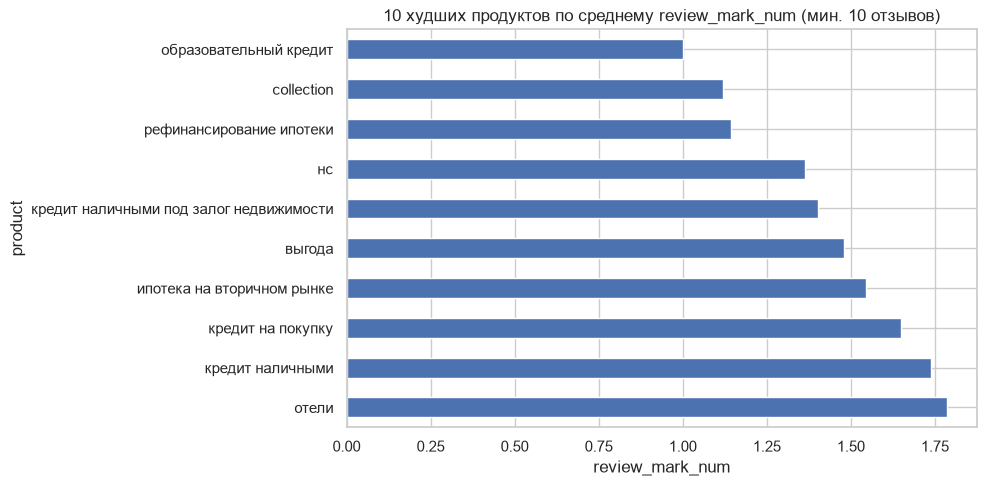

In [114]:
# Средняя оценка по продуктам (топ-10 худших)
plot_product_ranking(df, 'review_mark_num', top_n=10)
save_figure('worst_products_avg_mark.png')

Saved: C:\Users\Admin\Documents\PARA\Projects\product-analytics-intensive-case-tbank\reports\figures\product_emotion_heatmap.png


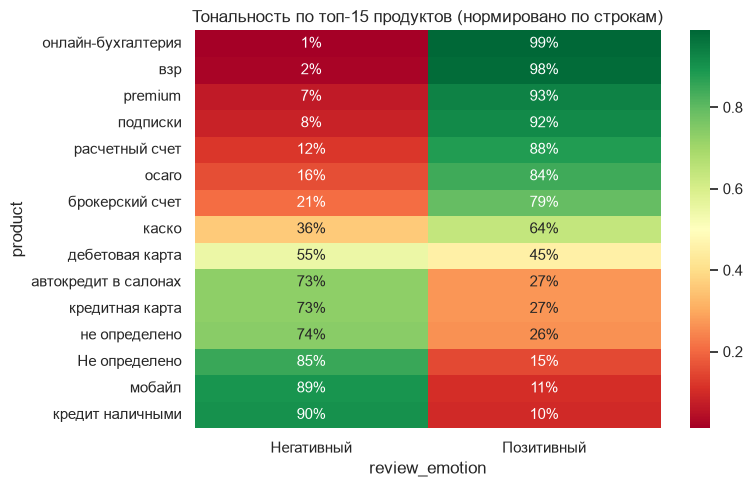

In [110]:
# Heatmap: product x review_emotion (топ-15 продуктов по частоте)
top_products = df['product'].value_counts().head(15).index
cross = pd.crosstab(
    df[df['product'].isin(top_products)]['product'],
    df[df['product'].isin(top_products)]['review_emotion'],
    normalize='index'
).sort_values('Негативный', ascending=True)
plot_satisfaction_heatmap(cross, 'Тональность по топ-15 продуктов (нормировано по строкам)', fmt='.0%')
save_figure('product_emotion_heatmap.png')

### 2c. Удовлетворённость по сегментам клиентов

In [116]:
# верификация: какой min_count в текущей функции?
import inspect
print(inspect.signature(plot_product_ranking))
print('---')
ranking_check = df.groupby('product')['review_mark_num'].agg(['mean', 'count']).sort_values('mean')
ranking_check = ranking_check[ranking_check['count'] >= 10]
print(ranking_check.head(15).to_string())

(df: pandas.DataFrame, metric_col: str, top_n: int = 10, min_count: int = 10)
---
                                             mean  count
product                                                 
образовательный кредит                   1.000000     11
collection                               1.120879     91
рефинансирование ипотеки                 1.142857     42
нс                                       1.363636     11
кредит наличными под залог недвижимости  1.401961    102
выгода                                   1.478261     23
ипотека на вторичном рынке               1.545455     55
кредит на покупку                        1.647482    139
кредит наличными                         1.738602    329
отели                                    1.785714     14
мобайл                                   1.827586    493
кубышка                                  1.925000     40
Не определено                            2.087912    455
кредит наличными под залог авто          2.260870     23
рефина

In [118]:
# смотрим, что за "collection"
collection_df = df[df['product'] == 'collection'][['product', 'business_line', 'reason', 'review_theme', 'subtheme', 'review_text']]
print(f'Всего записей: {len(collection_df)}')
print(collection_df.head(3).to_string())
print('---')
print('business_line:', collection_df['business_line'].unique())
print('reason:', collection_df['reason'].value_counts().head(5).to_string())
print('review_theme:', collection_df['review_theme'].value_counts().head(5).to_string())
print('subtheme:', collection_df['subtheme'].value_counts().head(5).to_string())

Всего записей: 155
         product    business_line         reason                   review_theme                             subtheme                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 

In [119]:
# что за "нс"
ns_df = df[df['product'] == 'нс'][['product', 'business_line', 'reason', 'review_theme', 'review_text']]
print(f'Всего записей: {len(ns_df)}')
print('business_line:', ns_df['business_line'].unique())
print('review_theme:', ns_df['review_theme'].value_counts().to_string())
print(ns_df[['product', 'business_line', 'review_theme']].head(5).to_string())

Всего записей: 14
business_line: <StringArray>
['страховая']
Length: 1, dtype: str
review_theme: review_theme
страховое событие      13
документы и справки     1
      product business_line       review_theme
4903       нс     страховая  страховое событие
7165       нс     страховая  страховое событие
10400      нс     страховая  страховое событие
13146      нс     страховая  страховое событие
19427      нс     страховая  страховое событие


Saved: C:\Users\Admin\Documents\PARA\Projects\product-analytics-intensive-case-tbank\reports\figures\detractor_share_by_segment.png


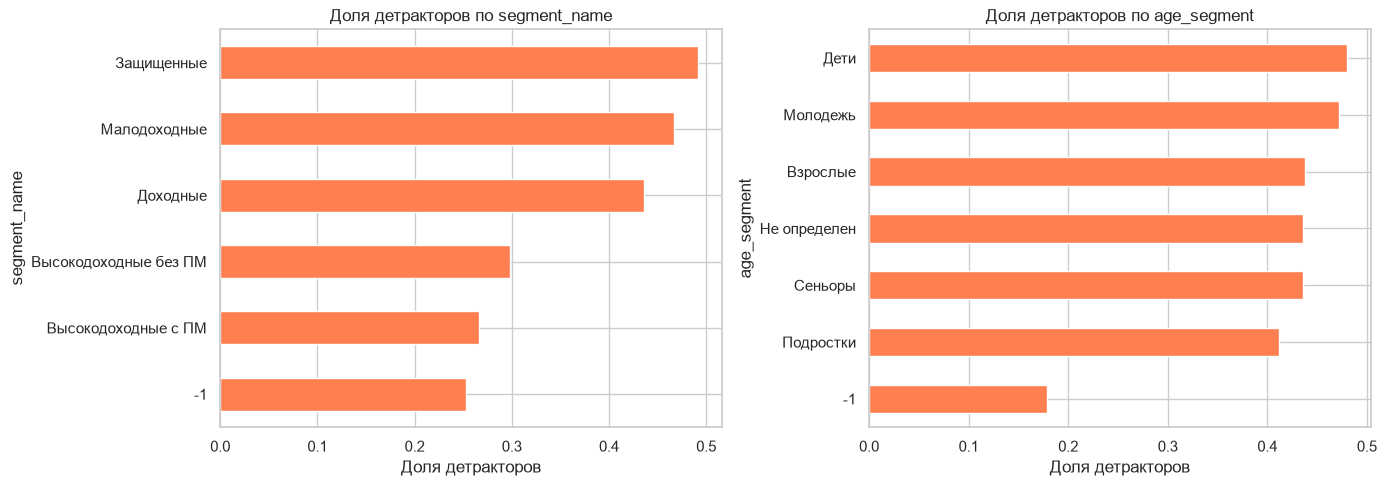

In [98]:
# Доля негатива по сегментам
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, col in enumerate(['segment_name', 'age_segment']):
    neg_share = df.groupby(col)['is_detractor'].mean().sort_values()
    neg_share.plot(kind='barh', ax=axes[i], title=f'Доля детракторов по {col}', color='coral')
    axes[i].set_xlabel('Доля детракторов')
plt.tight_layout()
save_figure('detractor_share_by_segment.png')

### 2d. Динамика удовлетворённости во времени

Saved: C:\Users\Admin\Documents\PARA\Projects\product-analytics-intensive-case-tbank\reports\figures\temporal_dynamics.png


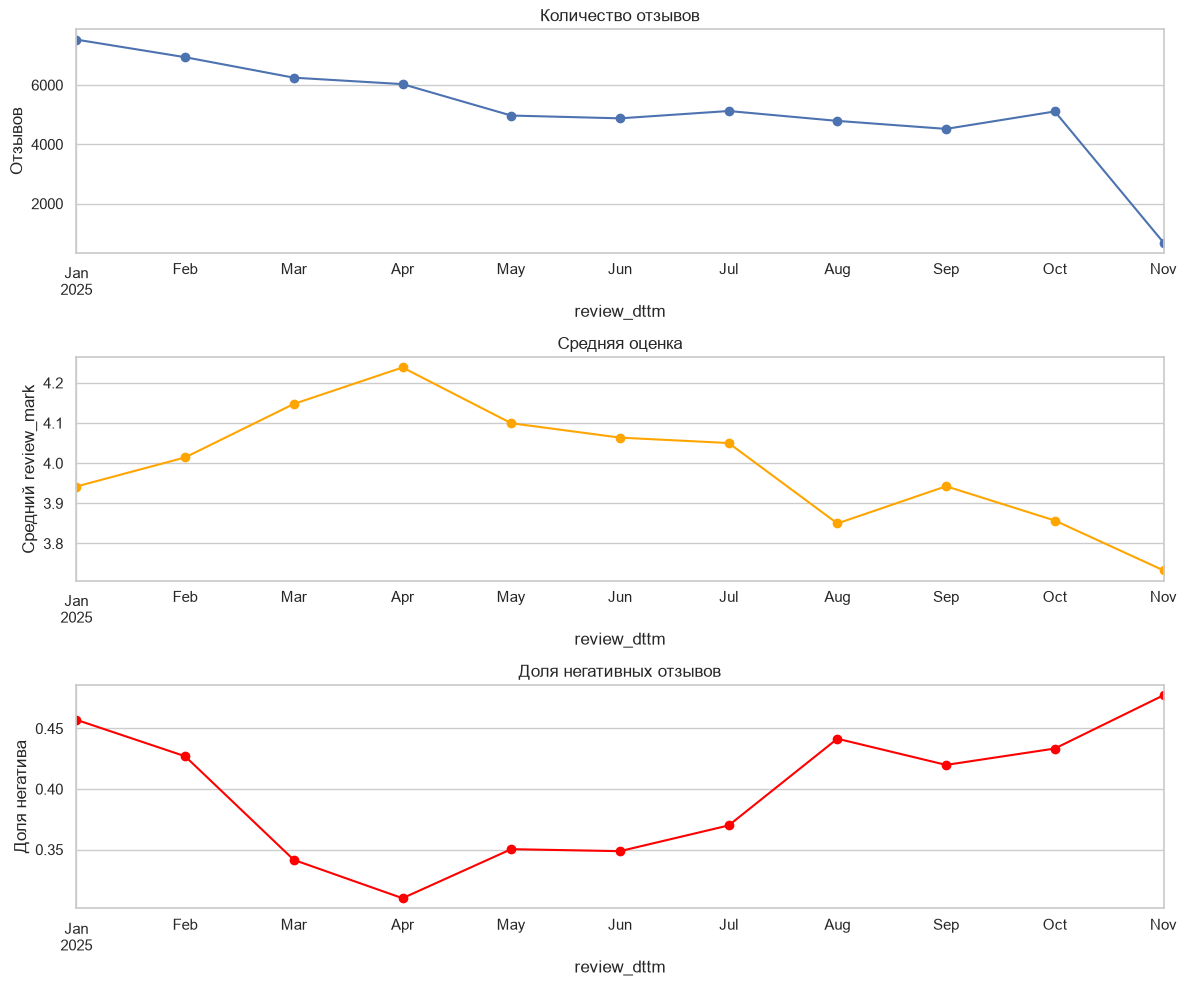

In [99]:
plot_temporal(df)
save_figure('temporal_dynamics.png')

## 3. Root Cause Analysis — выявление ключевых проблем

### 3a. Тематический анализ негатива

In [100]:
from src.analysis.stats import neg_share_by_group

# Топ-15 причин по частоте в негативе
reason_stats = neg_share_by_group(df, 'reason')
reason_stats.head(15)

,reason,total,neg_count,neg_share,avg_mark
0,Не определено,52452,17965,0.342504,4.187181
1,общая информация,311,309,0.993569,1.154762
2,заявки,216,215,0.995370,1.185484
3,акции,212,211,0.995283,1.221477
4,финансовая информация,169,169,1.000000,1.037037
5,документы,152,150,0.986842,1.217949
6,блокировка/разблокировка карты,141,141,1.000000,1.070423
7,повторное обращение,134,133,0.992537,1.220588
8,приложение и сайт тинькофф,105,104,0.990476,1.345455
9,ограничение операций,100,99,0.990000,1.176471


In [101]:
# Топ-15 подтем по частоте в негативе
subtheme_stats = neg_share_by_group(df, 'subtheme')
subtheme_stats.head(15)

,subtheme,total,neg_count,neg_share,avg_mark
0,блокировка карты,3583,3529,0.984929,1.273242
1,консультация по продукту,9605,1226,0.127642,4.810962
2,Не определено,966,856,0.886128,1.926591
3,отмена / оспаривание,3690,714,0.193496,4.521018
4,жалоба по страховому случаю,700,688,0.982857,1.299130
5,консультация по ограничениям и документам,1327,672,0.506405,3.724667
6,не был начислен,790,482,0.610127,2.898975
7,условия акции,978,477,0.487730,3.548223
8,обоснования наложения ограничений,472,468,0.991525,1.151625
9,консультация по ценным бумагам,609,464,0.761905,4.308571


Saved: C:\Users\Admin\Documents\PARA\Projects\product-analytics-intensive-case-tbank\reports\figures\biz_reason_detractor.png


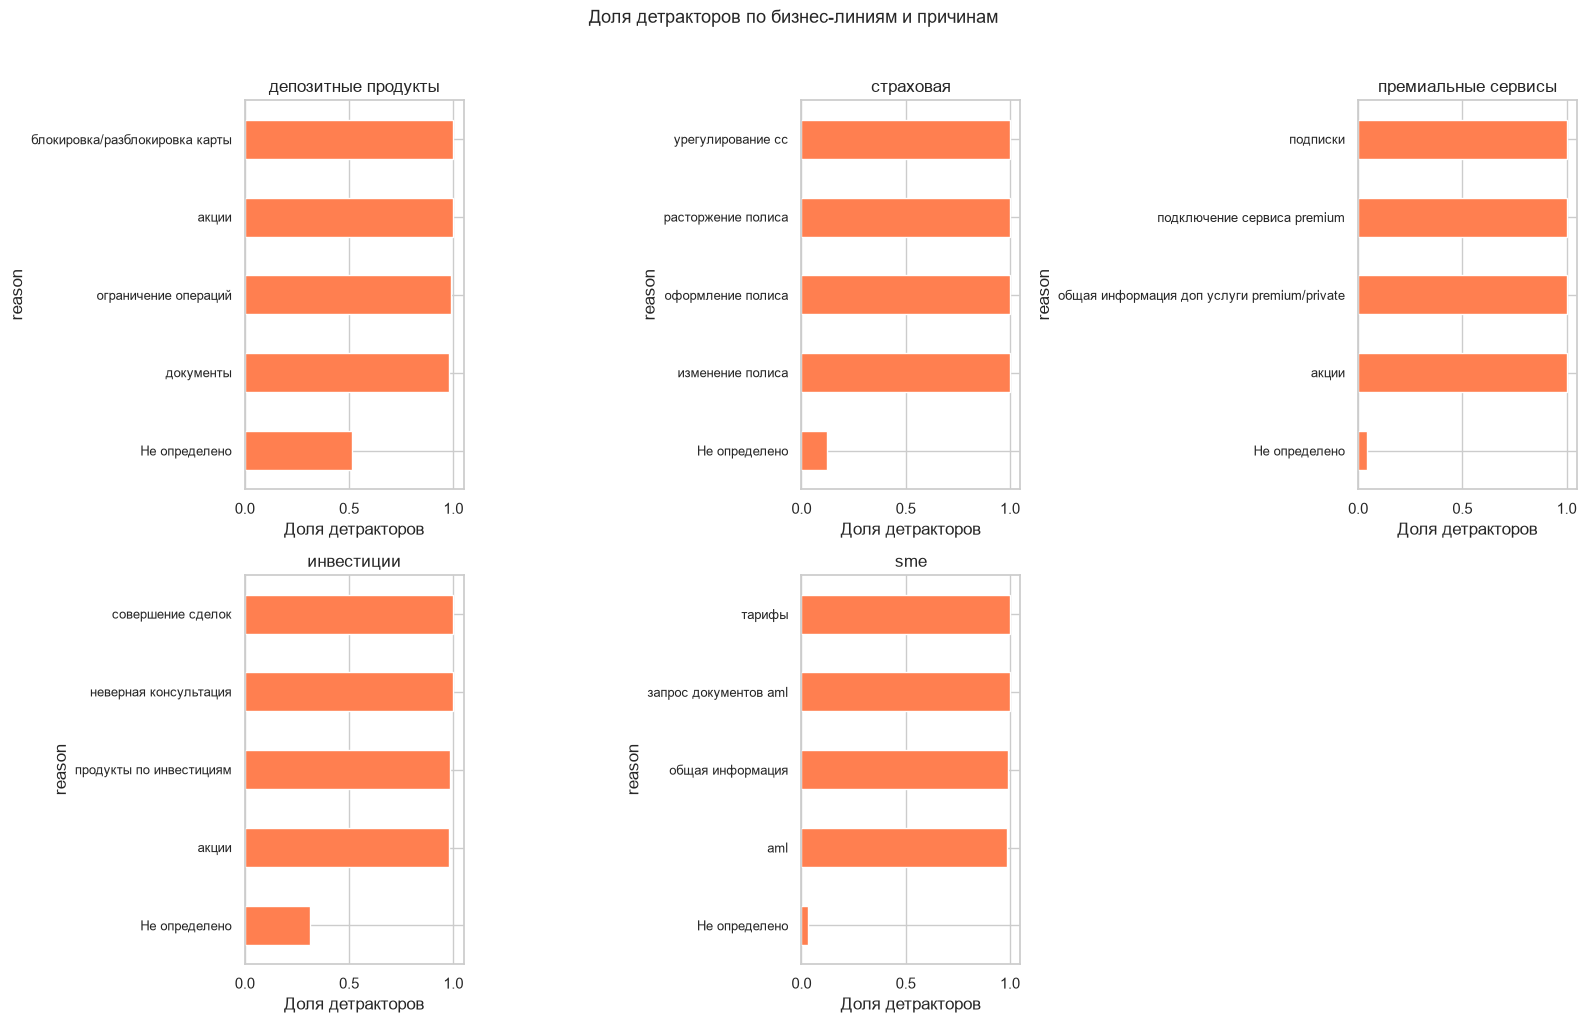

In [102]:
# Treemap: business_line -> reason -> доля негатива
# (альтернатива — группированная bar chart топ-5 reasons внутри каждой бизнес-линии)
top_biz = df['business_line'].value_counts().head(5).index
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()
for i, biz in enumerate(top_biz):
    subset = df[df['business_line'] == biz]
    top_reasons = subset['reason'].value_counts().head(5).index
    neg_by_reason = (
        subset[subset['reason'].isin(top_reasons)]
        .groupby('reason')['is_detractor']
        .mean()
        .sort_values()
    )
    neg_by_reason.plot(kind='barh', ax=axes[i], title=f'{biz}', color='coral')
    axes[i].set_xlabel('Доля детракторов')
    axes[i].tick_params(axis='y', labelsize=9)
axes[-1].axis('off')
plt.suptitle('Доля детракторов по бизнес-линиям и причинам', y=1.02)
plt.tight_layout()
save_figure('biz_reason_detractor.png')

In [103]:
# Сочетания product + reason с наибольшей долей негатива
df['product_reason'] = df['product'] + ' | ' + df['reason']
top_pairs = (
    df.groupby('product_reason')
    .agg(
        total=('is_detractor', 'size'),
        neg_share=('is_detractor', 'mean')
    )
    .query('total >= 20')
    .sort_values('neg_share', ascending=False)
    .head(15)
)
top_pairs

,total,neg_share
product_reason,,
collection | Не определено,139,1.0
premium | подключение сервиса premium,31,1.0
автокредит в салонах | финансовая информация,26,1.0
автокредит наличными | финансовая информация,29,1.0
premium | подписки,22,1.0
дебетовая карта | идентификация,43,1.0
дебетовая карта | заявки,46,1.0
дебетовая карта | кэшбэк,56,1.0
автокредит в салонах | общая информация,20,1.0


### 3b. Анализ текстов отзывов

In [104]:
from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud

# Разделим на позитив и негатив
neg_texts = df[df['is_detractor'] == 1]['review_text'].dropna()
pos_texts = df[df['is_detractor'] == 0]['review_text'].dropna()

print(f'Негативных текстов: {len(neg_texts)}')
print(f'Позитивных текстов: {len(pos_texts)}')

Негативных текстов: 20212
Позитивных текстов: 34511


In [105]:
# TF-IDF: топ-20 слов, дискриминирующих негатив
sample_neg = neg_texts.sample(min(3000, len(neg_texts)), random_state=42)
sample_pos = pos_texts.sample(min(3000, len(pos_texts)), random_state=42)

tfidf = TfidfVectorizer(max_features=5000, stop_words=None, ngram_range=(1, 2))
X = tfidf.fit_transform(pd.concat([sample_neg, sample_pos]))
y = np.array([1]*len(sample_neg) + [0]*len(sample_pos))

from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(C=1.0, max_iter=1000, solver='liblinear')
lr.fit(X, y)

coef_df = pd.DataFrame({
    'word': tfidf.get_feature_names_out(),
    'coef': lr.coef_[0]
}).sort_values('coef', ascending=False)

print('=== Топ-20 слов, характерных для НЕГАТИВА ===')
print(coef_df.head(20).to_string(index=False))
print()
print('=== Топ-20 слов, характерных для ПОЗИТИВА ===')
print(coef_df.tail(20).to_string(index=False))

=== Топ-20 слов, характерных для НЕГАТИВА ===
         word     coef
           не 5.678287
          нет 2.857185
        прошу 2.742235
       почему 2.608163
заблокировали 2.206701
  investments 2.202759
           вы 2.184560
      сказали 1.910952
 здравствуйте 1.847741
       кредит 1.579431
         банк 1.537651
           фз 1.513052
         хотя 1.494297
       теперь 1.482521
         могу 1.473923
          при 1.466050
           цб 1.465377
        ответ 1.442432
          они 1.424437
           то 1.389323

=== Топ-20 слов, характерных для ПОЗИТИВА ===
         word      coef
      помогли -2.116976
    поддержку -2.172852
        минут -2.205918
    поддержки -2.255656
        помог -2.409964
      помогла -2.458698
   обратилась -2.525634
      вернули -2.530206
      большое -2.580204
      вопросы -2.685032
    благодарю -2.709452
      приятно -2.719676
    обратился -2.747400
благодарность -3.008725
       всегда -3.155536
           за -3.449160
   оперативно -3

### 3c. Влияние решения проблемы на удовлетворённость

Saved: C:\Users\Admin\Documents\PARA\Projects\product-analytics-intensive-case-tbank\reports\figures\solution_impact.png


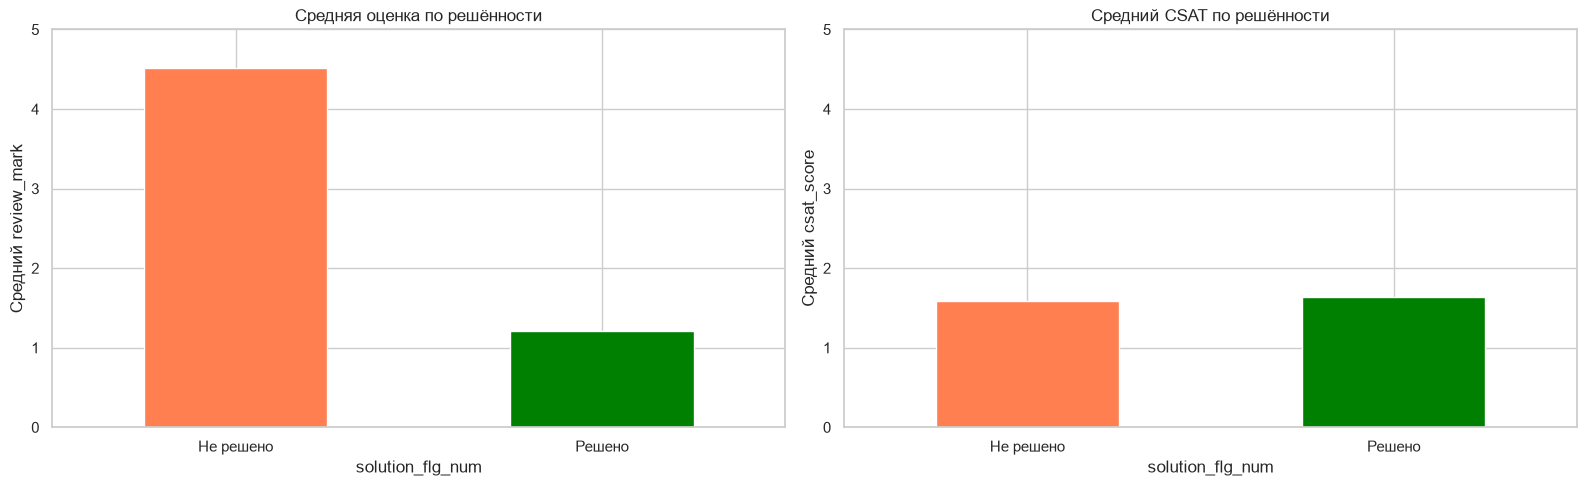

In [106]:
plot_solution_impact(df)
save_figure('solution_impact.png')

Saved: C:\Users\Admin\Documents\PARA\Projects\product-analytics-intensive-case-tbank\reports\figures\solution_by_biz.png


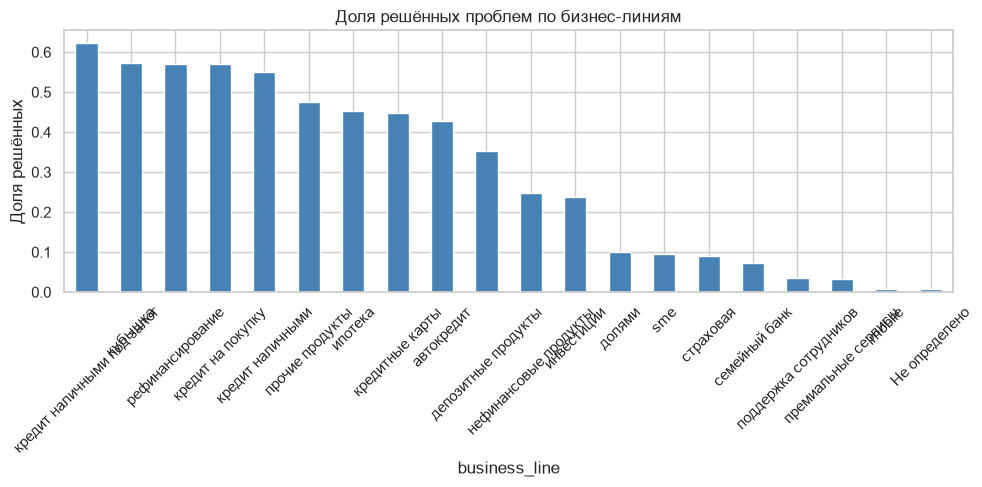

In [107]:
sol_by_biz = (
    df.groupby('business_line')['solution_flg_num']
    .agg(['mean', 'count'])
    .query('count >= 20')
    .sort_values('mean', ascending=False)
)
fig, ax = plt.subplots(figsize=(10, 5))
sol_by_biz['mean'].plot(kind='bar', ax=ax, title='Доля решённых проблем по бизнес-линиям', color='steelblue')
ax.set_ylabel('Доля решённых')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
save_figure('solution_by_biz.png')

## 4. Выводы

### 4.1. Связь метрик
- **`review_mark` и `review_emotion` практически взаимозаменяемы:** Spearman ρ = 0.977 (p < 0.001, n = 45 937). Нулевая доля противоречий.
- **CSAT умеренно коррелирует с тональностью:** Cramér's V = 0.325, Spearman ρ = 0.271. 10.6% негативных отзывов имеют CSAT = 5, что указывает на расхождение между прямой оценкой и расчётным CSAT.

### 4.2. Структура негатива
- **Доля детракторов:** 39.2% (22 285 отзывов).
- **Главная причина — блокировка карт:** 3 529 негативных отзывов (98.5%, средняя оценка 1.27).
- **Топ проблемных подтем:** блокировка карты, страховые случаи, обоснование ограничений, разблокировка, график платежей, отсрочки.
- **Тематические маркеры (TF-IDF):** слова-маркеры негатива — «заблокировали», «ФЗ», «ЦБ»; позитива — «спасибо», «быстро», «оперативно».

### 4.3. Сегменты и динамика
- **Новые клиенты (`new_flg=1`) дают больше позитива** — доля детракторов ниже среднего.
- **VIP-клиенты (influencer_flg=1) не отличаются** по уровню удовлетворённости от массового сегмента.
- **Решение проблемы** значимо повышает среднюю оценку и CSAT.

### 4.4. Рекомендации
1. **Автоматизировать процессы блокировки/разблокировки карт** — самая массовая причина негатива.
2. **Сократить долю повторных обращений** — 133 негативных (99.3%), индикатор нерешённых проблем.
3. **Пересмотреть методику расчёта CSAT** — расхождение с прямой оценкой клиента снижает доверие к метрике.
4. **Улучшить коммуникацию по страховым случаям** — 688 негативных отзывов (98.3%).


In [108]:
# Если проблема решена — как меняется оценка внутри того же продукта?
impact = (
    df.dropna(subset=['review_mark_num'])
    .groupby(['product', 'solution_flg'])['review_mark_num']
    .mean()
    .unstack()
)
impact['lift'] = impact[1] - impact[0] if 1 in impact.columns and 0 in impact.columns else 0
impact['lift'] = impact['lift'].fillna(0)
impact['total'] = df.groupby('product').size()
impact_sorted = impact[impact['total'] >= 30].sort_values('lift', ascending=False)
impact_sorted[['lift', 'total']].head(10)

solution_flg,lift,total
product,,
collection,0,155
junior,0,86
lifestyle,0,258
premium,0,6533
private,0,31
Не определено,0,698
автокредит в салонах,0,513
автокредит наличными,0,320
банкоматы,0,155
